In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

train_df = pd.read_csv("../data/processed/train_uci_household.csv", index_col="datetime", parse_dates=True)
val_df = pd.read_csv("../data/processed/val_uci_household.csv", index_col="datetime", parse_dates=True)
test_df = pd.read_csv("../data/processed/test_uci_household.csv", index_col="datetime", parse_dates=True)

print(train_df.shape, val_df.shape, test_df.shape)

TensorFlow version: 2.21.0
GPU available: []
(269772, 26) (62256, 26) (83007, 26)


In [2]:
feature_cols = [c for c in train_df.columns if not c.startswith("target_")]
target_col_name = "target_5min"  # starting with the 5-minute horizon first

X_train = train_df[feature_cols].values
y_train = train_df[target_col_name].values

X_val = val_df[feature_cols].values
y_val = val_df[target_col_name].values

X_test = test_df[feature_cols].values
y_test = test_df[target_col_name].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Feature columns used:", len(feature_cols))
print(X_train_scaled.shape, y_train.shape)

Feature columns used: 23
(269772, 23) (269772,)


In [3]:
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_val_lstm = X_val_scaled.reshape((X_val_scaled.shape[0], 1, X_val_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

print("LSTM input shape:", X_train_lstm.shape)

LSTM input shape: (269772, 1, 23)


In [4]:
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, input_shape=(1, X_train_lstm.shape[2]), return_sequences=False),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="mse", metrics=["mae"])
model.summary()

c:\Users\JESNI\powerpredict\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,641 (96.25 KB)

 Trainable params: 24,641 (96.25 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

history = model.fit(
    X_train_lstm, y_train,
    validation_data=(X_val_lstm, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
4216/4216 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.1826 - mae: 0.2259 - val_loss: 0.1311 - val_mae: 0.1935
Epoch 2/50
4216/4216 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 0.1508 - mae: 0.2051 - val_loss: 0.1289 - val_mae: 0.1970
Epoch 3/50
4216/4216 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 0.1459 - mae: 0.2011 - val_loss: 0.1249 - val_mae: 0.1964
Epoch 4/50
4216/4216 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 0.1436 - mae: 0.1986 - val_loss: 0.1229 - val_mae: 0.1870
Epoch 5/50
4216/4216 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 0.1416 - mae: 0.1959 - val_loss: 0.1264 - val_mae: 0.1998
Epoch 6/50
4216/4216 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 0.1396 - mae: 0.1943 - val_loss: 0.1222 - val_mae: 0.2000
Epoch 7/50
4216/4216 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 0.1389 - mae: 0.1933 - val_loss: 0.1244 - val_mae: 0.2075
Epoch 8/50
4216/4216 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 0.1378 - mae: 0.1920 - val_loss: 0.1238 - val_mae: 0.2037
Epoch 9/50
4216/4216 ━━━━━━━━━━━━━━━━━━━

In [6]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = model.predict(X_test_lstm).flatten()

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
wmape = np.sum(np.abs(y_test - y_pred)) / np.sum(np.abs(y_test)) * 100

print(f"RMSE:  {rmse:.4f}")
print(f"MAE:   {mae:.4f}")
print(f"R2:    {r2:.4f}")
print(f"wMAPE: {wmape:.2f}%")

2594/2594 ━━━━━━━━━━━━━━━━━━━━ 2s 735us/step
RMSE:  0.3166
MAE:   0.1813
R2:    0.8630
wMAPE: 18.07%


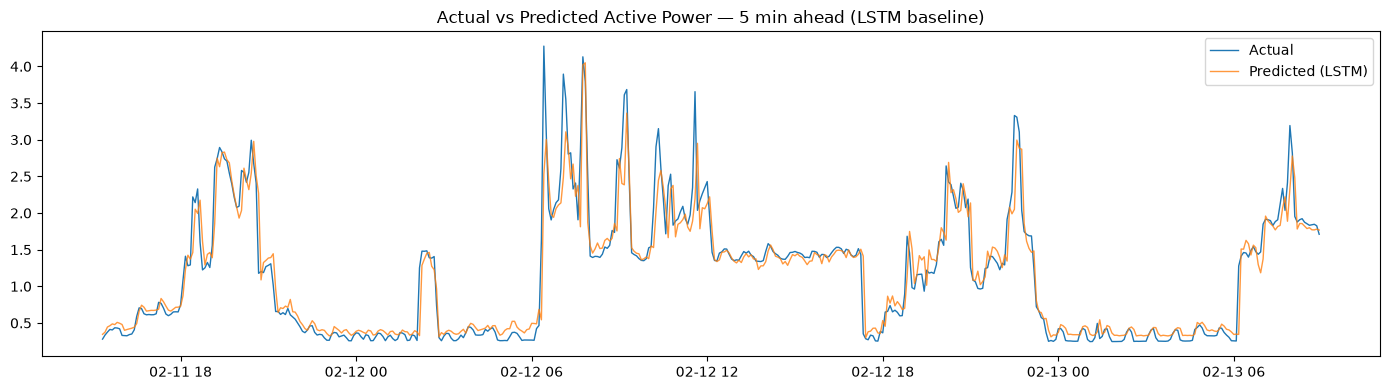

In [7]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(test_df.index[:500], y_test[:500], label="Actual", linewidth=1)
ax.plot(test_df.index[:500], y_pred[:500], label="Predicted (LSTM)", linewidth=1, alpha=0.8)
ax.set_title("Actual vs Predicted Active Power — 5 min ahead (LSTM baseline)")
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
import os
os.makedirs("../src/models/forecasting", exist_ok=True)
model.save("../src/models/forecasting/lstm_baseline_5min.keras")

print("Model saved.")

Model saved.
